
# CVA Sensitivity using AAD

This notebook demonstrates a work in progress implementation of CVA AAD sensitivities
- in the context of the scripted trade framework
- for a single Swap, as in Example 1

We highlight performance of the calculation and show differences between AAD and bump & revalue sensitivities.


## Recall: Run CVA using "classic" AMC
- AMC simulation generates the NPV cube, biweekly grid to 10 years, 8192 paths
- post processor step aggregates the expected exposure and copmputes CVA

In [2]:
import os

os.chdir('../Examples/Performance')

In [3]:
from ORE import *
import sys, time, math
sys.path.append('..')
import utilities

In [5]:
params_xva = Parameters()
params_xva.fromFile("Input/ore_amc_legacy.xml")
ore_xva = OREApp(params_xva)
ore_xva.run()
utilities.checkErrorsAndRunTime(ore_xva)
utilities.writeList(ore_xva.getReportNames())

Run time: 6.87 sec
Errors: 1
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000510) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva cam building" }, { "name": "exceptionType", "value": "Failed to calibrate LGM Model. Calculation will proceed." } ] }

- cashflow
- colva_nettingset_CPTY_A
- cva_sensitivity_nettingset_CPTY_A
- dividends
- exposure_nettingset_CPTY_A
- exposure_trade_Swap_20
- fixings
- marketdata
- npv
- pricingstats
- runtimes
- todaysmarketcalibration
- xva


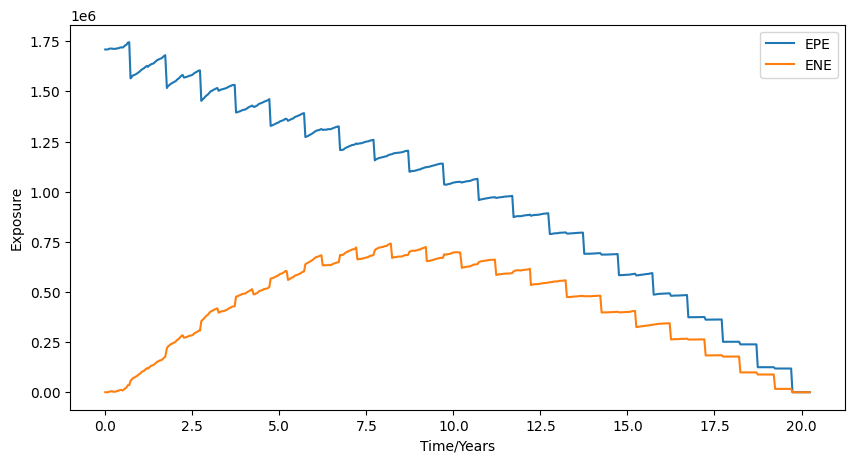

In [6]:
# plot the exposure report
exposure_report = ore_xva.getReport("exposure_nettingset_CPTY_A")
time = exposure_report.dataAsReal(2)
epe = exposure_report.dataAsReal(3)
ene = exposure_report.dataAsReal(4)

import matplotlib.pyplot as plt
fig = plt.figure(figsize=(10, 5))
plt.plot(time, epe, label='EPE')
plt.plot(time, ene, label='ENE')
plt.xlabel('Time/Years')
plt.ylabel('Exposure')
plt.title('')
plt.legend()
plt.show()

In [7]:
# show the xva report
xva_report = ore_xva.getReport("xva")
display(utilities.format_report(xva_report))

,TradeId,NettingSetId,CVA,DVA,FBA,FCA,FBAexOwnSP,FCAexOwnSP,FBAexAllSP,FCAexAllSP,...,OurKVACCR,TheirKVACCR,OurKVACVA,TheirKVACVA,CollateralFloor,AllocatedCVA,AllocatedDVA,AllocationMethod,BaselEPE,BaselEEPE
0,,CPTY_A,110350.667723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,110350.667723,0.0,None,1.675786e+06,1.725968e+06
1,Swap_20,CPTY_A,110350.667723,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.402823e+38,3.402823e+38,3.402823e+38,3.402823e+38,3.402823e+38,0.000000,0.0,None,1.675786e+06,1.725968e+06


## Run CVA on the Computation Graph
We use a proof of concept implementation (see orea/engine/xvaenginecg.xpp) called from the XVA analytic (see orea/app/analytics/xvaanalytic.cpp) if parameter **amcCg=true** in ore_ad.xml.

This engine performes AMC valuation, exposure aggregation and XVA calculation in one shot on ORE's ComputationGraph. 

We can force calculation of sensitivities by bump & revalue if parameter **xvaCgBumpSensis=true**, see ore_bump.xml. This is what we do below, to generate "reference" sensitivities.


In [10]:
params = Parameters()
params.fromFile("Input/ore_cvasensi_bump.xml")
ore = OREApp(params)
ore.run()
utilities.checkErrorsAndRunTime(ore)
utilities.writeList(ore.getReportNames())

Run time: 58.95 sec
Errors: 6
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000510) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva engine cg - cam builder" }, { "name": "exceptionType", "value": "Failed to calibrate LGM Model. Calculation will proceed." } ] }
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000509) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva engine cg - cam builder" }, { "name": "exceptionType", "value": "Failed to calibrate LGM Model. Calculation will proceed." } ] }
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000503) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva engine cg - cam builder" }, { "name": "exceptionType", "value": "Failed to calibrate 

In [11]:
exposure = ore.getReport("xvacg-exposure")
display(utilities.format_report(exposure))

,Date,EPE,ENE
0,2016-02-05,1.695615e+06,0.000000
1,2016-02-19,1.695653e+06,38.516970
2,2016-03-04,1.695615e+06,0.000000
3,2016-03-18,1.695615e+06,0.000000
4,2016-04-01,1.695751e+06,135.582798
...,...,...,...
524,2036-03-07,0.000000e+00,-0.000000
525,2036-03-21,0.000000e+00,-0.000000
526,2036-04-04,0.000000e+00,-0.000000
527,2036-04-18,0.000000e+00,-0.000000


In [12]:
sensi_scenario_bump = ore.getReport("xvacg-cva-sensi-scenario")
display(utilities.format_report(sensi_scenario_bump))

,TradeId,Factor,Up/Down,Base NPV,ShiftSize_1,ShiftSize_2,Scenario NPV,Difference
0,CVA,DiscountCurve/EUR/1/1M,Up,296464.416212,1.000000e-06,3.402823e+38,296464.416212,1.402805e-08
1,CVA,DiscountCurve/EUR/2/3M,Up,296464.416212,1.000000e-06,3.402823e+38,296464.416212,3.441819e-07
2,CVA,DiscountCurve/EUR/3/6M,Up,296464.416212,1.000000e-06,3.402823e+38,296464.415562,-6.497510e-04
3,CVA,DiscountCurve/EUR/4/1Y,Up,296464.416212,1.000000e-06,3.402823e+38,296464.413500,-2.711601e-03
4,CVA,DiscountCurve/EUR/5/2Y,Up,296464.416212,1.000000e-06,3.402823e+38,296464.403057,-1.315472e-02
...,...,...,...,...,...,...,...,...
66,CVA,SurvivalProbability/BANK/6/3Y,Up,296464.416212,1.000000e-06,3.402823e+38,296464.703237,2.870254e-01
67,CVA,SurvivalProbability/BANK/7/5Y,Up,296464.416212,1.000000e-06,3.402823e+38,296465.469327,1.053116e+00
68,CVA,SurvivalProbability/BANK/8/10Y,Up,296464.416212,1.000000e-06,3.402823e+38,296467.482568,3.066356e+00
69,CVA,SurvivalProbability/BANK/9/15Y,Up,296464.416212,1.000000e-06,3.402823e+38,296470.511070,6.094858e+00


## Run CVA Sensitivity using AAD

In [9]:
params_ad = Parameters()
params_ad.fromFile("Input/ore_cvasensi_ad.xml")
ore_ad = OREApp(params_ad)
ore_ad.run()
utilities.checkErrorsAndRunTime(ore_ad)

Run time: 2.78 sec
Errors: 6
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000510) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva engine cg - cam builder" }, { "name": "exceptionType", "value": "Failed to calibrate LGM Model. Calculation will proceed." } ] }
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000509) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva engine cg - cam builder" }, { "name": "exceptionType", "value": "Failed to calibrate LGM Model. Calculation will proceed." } ] }
{ "category": "Warning", "group": "Model", "message": "LGM (EUR) calibration target function value (0.000503) exceeds notification threshold (0.000100).", "sub_fields": [ { "name": "context-id", "value": "xva engine cg - cam builder" }, { "name": "exceptionType", "value": "Failed to calibrate L

In [13]:
# Compare Sensitivity Scenarios
utilities.match_scenario_reports(ore, ore_ad, False)

Factor                                   Scenario       Delta1     Delta2       Diff
DiscountCurve/EUR/1/1M                           Up       0.00       0.00      -0.00
DiscountCurve/EUR/2/3M                           Up       0.00       0.00      -0.00
DiscountCurve/EUR/3/6M                           Up      -0.00      -0.00      -0.00
DiscountCurve/EUR/4/1Y                           Up      -0.00      -0.00      -0.00
DiscountCurve/EUR/5/2Y                           Up      -0.01      -0.01      -0.00
DiscountCurve/EUR/6/3Y                           Up      -0.04      -0.04       0.00
DiscountCurve/EUR/7/5Y                           Up      -0.20      -0.20       0.00
DiscountCurve/EUR/8/10Y                          Up      -0.68      -0.68       0.00
DiscountCurve/EUR/9/15Y                          Up      -1.43      -1.43       0.00
DiscountCurve/EUR/10/20Y                         Up      -1.36      -1.36      -0.00
IndexCurve/EUR-EONIA/4/1Y                        Up       0.00   

## Summary

Swap example performance (Macbook Pro, Apple M2 Max 2023) 
- ~9 seconds run time for CVA with "classic" AMC simulation and postprocessing for exposure and CVA
- ~44 seconds run time for CVA Sensitivities, ComputationGraph, Bump & Reval
- ~5 seconds run time for CVA Sensitivities with AAD